In [1]:

!pip install scikit-learn pandas matplotlib numpy

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

print("✅ Libraries loaded!")

Access is denied.


✅ Libraries loaded!


In [2]:
# Cell 2: Load Dataset
df = pd.read_csv('fuel_prices_1970_2026.csv')  # adjust path if needed
df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values('Date').reset_index(drop=True)
df['Price'] = pd.to_numeric(df['Crude_Oil_Price'], errors='coerce')
df.dropna(inplace=True)

print(df.shape)
print(df.tail())

(675, 3)
          Date  Crude_Oil_Price  Price
670 2025-11-01            59.46  59.46
671 2025-12-01            57.95  57.95
672 2026-01-01            60.04  60.04
673 2026-02-01            64.47  64.47
674 2026-03-01            87.84  87.84


In [3]:
# Cell 3: Feature Engineering
df['Year']       = df['Date'].dt.year
df['Month']      = df['Date'].dt.month
df['Time_Index'] = np.arange(len(df))

# Lag features
df['Lag_1']  = df['Price'].shift(1)
df['Lag_3']  = df['Price'].shift(3)
df['Lag_6']  = df['Price'].shift(6)
df['Lag_12'] = df['Price'].shift(12)

# Rolling mean
df['Rolling_3']  = df['Price'].rolling(3).mean()
df['Rolling_12'] = df['Price'].rolling(12).mean()

df.dropna(inplace=True)
df.reset_index(drop=True, inplace=True)

features = ['Time_Index','Year','Month','Lag_1','Lag_3','Lag_6','Lag_12','Rolling_3','Rolling_12']
X = df[features]
y = df['Price']

print(f"✅ Features ready — {X.shape[0]} rows, {X.shape[1]} features")

✅ Features ready — 663 rows, 9 features


In [4]:
# Cell 4: Train-Test Split (80/20 chronological)
split = int(len(df) * 0.8)
X_train, X_test = X.iloc[:split], X.iloc[split:]
y_train, y_test = y.iloc[:split], y.iloc[split:]
dates_test = df['Date'].iloc[split:]

print(f"Train: {len(X_train)} | Test: {len(X_test)}")

Train: 530 | Test: 133


In [5]:
# Cell 5: Train Linear Regression & Random Forest
lr  = LinearRegression()
rf  = RandomForestRegressor(n_estimators=200, random_state=42)

lr.fit(X_train, y_train)
rf.fit(X_train, y_train)

lr_pred = lr.predict(X_test)
rf_pred = rf.predict(X_test)

# Metrics
lr_mae = mean_absolute_error(y_test, lr_pred)
rf_mae = mean_absolute_error(y_test, rf_pred)
lr_r2  = r2_score(y_test, lr_pred)
rf_r2  = r2_score(y_test, rf_pred)

print(f"Linear Regression  → MAE: {lr_mae:.2f}  R²: {lr_r2:.3f}")
print(f"Random Forest      → MAE: {rf_mae:.2f}  R²: {rf_r2:.3f}")

Linear Regression  → MAE: 2.59  R²: 0.965
Random Forest      → MAE: 3.84  R²: 0.915


In [6]:
# Cell 6: Forecast future 24 months (2026-2027)
last_row   = df.iloc[-1]
last_price = last_row['Price']
last_idx   = last_row['Time_Index']
last_date  = last_row['Date']
history    = list(df['Price'].values)

future_dates  = pd.date_range(start=last_date + pd.DateOffset(months=1), periods=24, freq='MS')
future_preds  = []

rolling_window = list(df['Price'].values[-12:])  # keep last 12 prices

for i, fdate in enumerate(future_dates):
    new_idx = last_idx + i + 1
    lag1    = rolling_window[-1]
    lag3    = rolling_window[-3]  if len(rolling_window) >= 3  else lag1
    lag6    = rolling_window[-6]  if len(rolling_window) >= 6  else lag1
    lag12   = rolling_window[-12] if len(rolling_window) >= 12 else lag1
    roll3   = np.mean(rolling_window[-3:])
    roll12  = np.mean(rolling_window[-12:])

    row = pd.DataFrame([[new_idx, fdate.year, fdate.month,
                         lag1, lag3, lag6, lag12, roll3, roll12]],
                       columns=features)
    pred = rf.predict(row)[0]
    future_preds.append(pred)
    rolling_window.append(pred)

forecast_df = pd.DataFrame({'Date': future_dates, 'Forecast': future_preds})
forecast_df['Lower'] = forecast_df['Forecast'] * 0.85
forecast_df['Upper'] = forecast_df['Forecast'] * 1.15
print(forecast_df.head())

        Date   Forecast      Lower      Upper
0 2026-04-01  77.001564  65.451329  88.551798
1 2026-05-01  79.091056  67.227398  90.954714
2 2026-06-01  81.108472  68.942201  93.274743
3 2026-07-01  81.114162  68.947038  93.281287
4 2026-08-01  81.378164  69.171440  93.584889


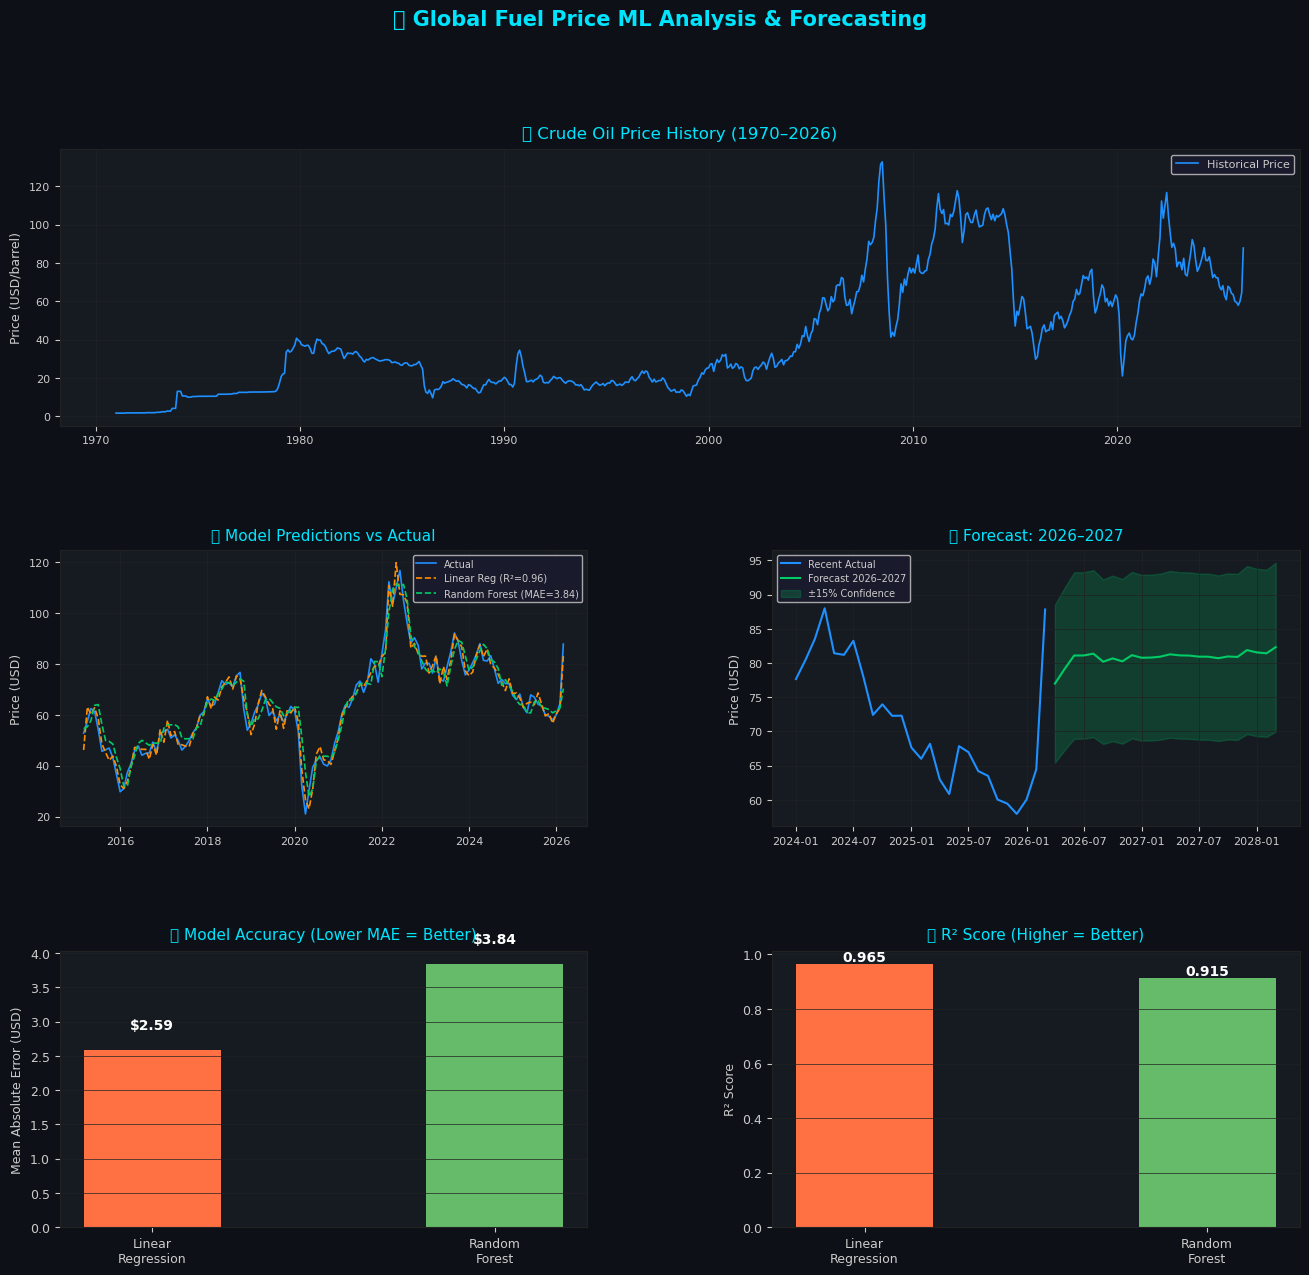

In [7]:
# Cell 7: Full Dashboard Plot
fig = plt.figure(figsize=(16, 14), facecolor='#0d1117')
gs  = gridspec.GridSpec(3, 2, figure=fig, hspace=0.45, wspace=0.35)

title_color  = '#00e5ff'
text_color   = '#cccccc'
grid_color   = '#222222'
line_blue    = '#1e90ff'
line_orange  = '#ff8c00'
line_green   = '#00cc66'
bar_orange   = '#ff7043'
bar_green    = '#66bb6a'
bg_panel     = '#161b22'

# ── 1. Crude Oil Price History (top, full width) ──────────────────────────
ax1 = fig.add_subplot(gs[0, :])
ax1.set_facecolor(bg_panel)
ax1.plot(df['Date'], df['Price'], color=line_blue, linewidth=1.2, label='Historical Price')
ax1.set_title('📈 Crude Oil Price History (1970–2026)', color=title_color, fontsize=12, pad=8)
ax1.set_ylabel('Price (USD/barrel)', color=text_color, fontsize=9)
ax1.tick_params(colors=text_color, labelsize=8)
ax1.legend(facecolor='#1a1a2e', labelcolor=text_color, fontsize=8)
ax1.grid(color=grid_color, linewidth=0.5)
for spine in ax1.spines.values(): spine.set_edgecolor(grid_color)

# ── 2. Model Predictions vs Actual ───────────────────────────────────────
ax2 = fig.add_subplot(gs[1, 0])
ax2.set_facecolor(bg_panel)
ax2.plot(dates_test, y_test.values, color=line_blue, linewidth=1.2, label='Actual')
ax2.plot(dates_test, lr_pred, color=line_orange, linewidth=1.2, linestyle='--',
         label=f'Linear Reg (R²={lr_r2:.2f})')
ax2.plot(dates_test, rf_pred, color=line_green, linewidth=1.2, linestyle='--',
         label=f'Random Forest (MAE={rf_mae:.2f})')
ax2.set_title('🤖 Model Predictions vs Actual', color=title_color, fontsize=11, pad=8)
ax2.set_ylabel('Price (USD)', color=text_color, fontsize=9)
ax2.tick_params(colors=text_color, labelsize=8)
ax2.legend(facecolor='#1a1a2e', labelcolor=text_color, fontsize=7)
ax2.grid(color=grid_color, linewidth=0.5)
for spine in ax2.spines.values(): spine.set_edgecolor(grid_color)

# ── 3. Forecast 2026-2027 ────────────────────────────────────────────────
ax3 = fig.add_subplot(gs[1, 1])
ax3.set_facecolor(bg_panel)
recent = df[df['Date'] >= '2024-01-01']
ax3.plot(recent['Date'], recent['Price'], color=line_blue, linewidth=1.5, label='Recent Actual')
ax3.plot(forecast_df['Date'], forecast_df['Forecast'], color=line_green, linewidth=1.5,
         label='Forecast 2026–2027')
ax3.fill_between(forecast_df['Date'], forecast_df['Lower'], forecast_df['Upper'],
                 color=line_green, alpha=0.2, label='±15% Confidence')
ax3.set_title('🔮 Forecast: 2026–2027', color=title_color, fontsize=11, pad=8)
ax3.set_ylabel('Price (USD)', color=text_color, fontsize=9)
ax3.tick_params(colors=text_color, labelsize=8)
ax3.legend(facecolor='#1a1a2e', labelcolor=text_color, fontsize=7)
ax3.grid(color=grid_color, linewidth=0.5)
for spine in ax3.spines.values(): spine.set_edgecolor(grid_color)

# ── 4. MAE Bar Chart ──────────────────────────────────────────────────────
ax4 = fig.add_subplot(gs[2, 0])
ax4.set_facecolor(bg_panel)
bars = ax4.bar(['Linear\nRegression', 'Random\nForest'],
               [lr_mae, rf_mae], color=[bar_orange, bar_green], width=0.4)
ax4.set_title('📊 Model Accuracy (Lower MAE = Better)', color=title_color, fontsize=11, pad=8)
ax4.set_ylabel('Mean Absolute Error (USD)', color=text_color, fontsize=9)
ax4.tick_params(colors=text_color, labelsize=9)
ax4.grid(color=grid_color, linewidth=0.5, axis='y')
for bar, val in zip(bars, [lr_mae, rf_mae]):
    ax4.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
             f'${val:.2f}', ha='center', color='white', fontsize=10, fontweight='bold')
for spine in ax4.spines.values(): spine.set_edgecolor(grid_color)

# ── 5. R² Bar Chart ───────────────────────────────────────────────────────
ax5 = fig.add_subplot(gs[2, 1])
ax5.set_facecolor(bg_panel)
bars2 = ax5.bar(['Linear\nRegression', 'Random\nForest'],
                [lr_r2, rf_r2], color=[bar_orange, bar_green], width=0.4)
ax5.set_title('📉 R² Score (Higher = Better)', color=title_color, fontsize=11, pad=8)
ax5.set_ylabel('R² Score', color=text_color, fontsize=9)
ax5.tick_params(colors=text_color, labelsize=9)
ax5.grid(color=grid_color, linewidth=0.5, axis='y')
for bar, val in zip(bars2, [lr_r2, rf_r2]):
    ax5.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
             f'{val:.3f}', ha='center', color='white', fontsize=10, fontweight='bold')
for spine in ax5.spines.values(): spine.set_edgecolor(grid_color)

# ── Super title ───────────────────────────────────────────────────────────
fig.suptitle('⛽ Global Fuel Price ML Analysis & Forecasting',
             color=title_color, fontsize=15, fontweight='bold', y=0.98)

plt.savefig('fuel_ml_dashboard.png', dpi=150, bbox_inches='tight', facecolor='#0d1117')
plt.show()